# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [1]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [ ]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE

# --- AVL Tree helpers ---

class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None
        self.height = 1

def height(node):
    if not node:
        return 0
    return node.height

def AVLBalance(node):
    if not node:
        return 0
    return height(node.left) - height(node.right)

def AVLRotateRight(n):
    m = n.left
    l = m.right
    m.right = n
    n.left = l
    n.height = 1 + max(height(n.left), height(n.right))
    m.height = 1 + max(height(m.left), height(m.right))
    return m

def AVLRotateLeft(n):
    m = n.right
    l = m.left
    m.left = n
    n.right = l
    n.height = 1 + max(height(n.left), height(n.right))
    m.height = 1 + max(height(m.left), height(m.right))
    return m

def AVLInsertHelper(self, node, value):
    if not node:
        self.inserted = True
        return Node(value)
    if value < node.value:
        node.left = AVLInsertHelper(self, node.left, value)
    elif value > node.value:
        node.right = AVLInsertHelper(self, node.right, value)
    else:
        return node
    node.height = 1 + max(height(node.left), height(node.right))
    b = AVLBalance(node)
    if b < -1:  # right-heavy
        if AVLBalance(node.right) > 0:  # right-left case
            node.right = AVLRotateRight(node.right)
        return AVLRotateLeft(node)
    elif b > 1:  # left-heavy
        if AVLBalance(node.left) < 0:  # left-right case
            node.left = AVLRotateLeft(node.left)
        return AVLRotateRight(node)
    return node

def searchHelper(node, value):
    while node is not None:
        if value < node.value:
            node = node.left
        elif value > node.value:
            node = node.right
        else:
            return True
    return False


# --- 2-3 Tree helpers ---

class TwoThreeNode:
    __slots__ = ("keyList", "keyCount", "childList", "parentNode")

    def __init__(self, keyList=None, childList=None, parentNode=None):
        self.keyList = list(keyList) if keyList is not None else []
        self.keyCount = len(self.keyList)
        self.childList = list(childList) if childList is not None else []
        self.parentNode = parentNode
        if self.childList:
            for childNode in self.childList:
                childNode.parentNode = self

    def GetKeyCount(self):
        self.keyCount = len(self.keyList)
        return self.keyCount

    def IsLeaf(self):
        return len(self.childList) == 0

    def IsOverflow(self):
        return self.GetKeyCount() == 3

    def InsertKey(self, keyValue):
        self.keyList.append(keyValue)
        self.keyList.sort()
        self.GetKeyCount()
        return self.keyList.index(keyValue)

    def ChildIndexFor(self, keyValue):
        indexValue = 0
        while indexValue < self.GetKeyCount() and keyValue >= self.keyList[indexValue]:
            indexValue += 1
        return indexValue

    def SetChildren(self, childList):
        self.childList = list(childList)
        for childNode in self.childList:
            childNode.parentNode = self


# --- LLRB BST helpers ---

RED = True
BLACK = False


class LLRBNode:
    """A single node in the LLRB BST, carrying a key, a value, and a link colour."""

    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None
        self.color = RED  # new nodes are always inserted as red


def _is_red(node):
    """Return True if node's incoming link is red; None links are black."""
    if node is None:
        return False
    return node.color == RED


def _rotate_left(h):
    """
    Rotate h left to eliminate a right-leaning red link.

    Before:  h -red-> x        After:  x
                      / \             / \
                     b   c         red h   c
                                   / \
                                  a   b

    Operations:
      1. x (h.right) becomes the new subtree root.
      2. x's left subtree is transferred to h as its new right child.
      3. h becomes x's left child.
      4. x inherits h's original colour (subtree colour unchanged externally).
      5. h is coloured RED (link from x down to h is now red).

    Returns the new subtree root x.
    """
    x = h.right
    h.right = x.left
    x.left = h
    x.color = h.color
    h.color = RED
    return x


def _rotate_right(h):
    """
    Rotate h right to eliminate two consecutive left-leaning red links.

    Before:     h              After:  x
               / \                   / \
           red x   c               a   red h
           / \                         / \
          a   b                        b   c

    Operations:
      1. x (h.left) becomes the new subtree root.
      2. x's right subtree is transferred to h as its new left child.
      3. h becomes x's right child.
      4. x inherits h's original colour (subtree colour unchanged externally).
      5. h is coloured RED (link from x down to h is now red).

    Returns the new subtree root x.
    """
    x = h.left
    h.left = x.right
    x.right = h
    x.color = h.color
    h.color = RED
    return x


def _flip_colors(h):
    """
    Flip colours of h and both children to split a temporary 4-node.

    Operations:
      1. h is coloured RED  - propagates the carry up to h's parent.
      2. h.left  is coloured BLACK.
      3. h.right is coloured BLACK.

    Modifies nodes in place; returns nothing.
    """
    h.color = RED
    h.left.color = BLACK
    h.right.color = BLACK


def _llrb_put(h, key, value):
    """
    Recursive insert into the subtree rooted at h.

    Going DOWN:
      - h is None          -> create and return a new red LLRBNode.
      - key < h.key        -> recurse left.
      - key > h.key        -> recurse right.
      - key == h.key       -> update value in place (no structural change).

    Coming BACK UP (three fix-up checks in order):
      1. Right child red, left child not red  -> rotate_left  (no right-leaning reds).
      2. Left child red and left-left red     -> rotate_right (no two consecutive reds).
      3. Both children red                   -> flip_colors  (split 4-node).

    Returns the (possibly new) subtree root after fix-ups.
    """
    if h is None:
        return LLRBNode(key, value)

    if key < h.key:
        h.left = _llrb_put(h.left, key, value)
    elif key > h.key:
        h.right = _llrb_put(h.right, key, value)
    else:
        h.value = value  # duplicate key: update value

    if _is_red(h.right) and not _is_red(h.left):
        h = _rotate_left(h)
    if _is_red(h.left) and _is_red(h.left.left):
        h = _rotate_right(h)
    if _is_red(h.left) and _is_red(h.right):
        _flip_colors(h)

    return h


def _llrb_contains(root, key):
    """
    Iterative BST search (colour is irrelevant for lookup).

    Traversal:
      - key < node.key  -> go left.
      - key > node.key  -> go right.
      - key == node.key -> found; return True.
      - node is None    -> exhausted; return False.

    Returns True if key exists in the tree, False otherwise.
    """
    node = root
    while node is not None:
        if key < node.key:
            node = node.left
        elif key > node.key:
            node = node.right
        else:
            return True
    return False

Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [3]:
class TwoThreeTree(AbstractSearchInterface):

    def __init__(self, stringValue=None):
        self.rootNode = None
        if stringValue is not None:
            for elementValue in stringValue:
                self.insertElement(elementValue)

    def insertElement(self, elementValue):
        if self.rootNode is None:
            self.rootNode = TwoThreeNode([elementValue])
            return True

        # traverse to leaf, checking for duplicates at each internal node
        currentNode = self.rootNode
        while not currentNode.IsLeaf():
            if elementValue in currentNode.keyList:
                return False
            childIndexValue = currentNode.ChildIndexFor(elementValue)
            currentNode = currentNode.childList[childIndexValue]

        # check for duplicate at leaf
        if elementValue in currentNode.keyList:
            return False

        currentNode.InsertKey(elementValue)

        # fix 4-nodes up the tree
        while currentNode is not None and currentNode.IsOverflow():
            self.SplitNode(currentNode)
            currentNode = currentNode.parentNode

        return True

    def searchElement(self, elementValue):
        found = False

        currentNode = self.rootNode
        while currentNode is not None:
            keyIndexValue = 0
            while keyIndexValue < currentNode.keyCount:
                if elementValue == currentNode.keyList[keyIndexValue]:
                    return True
                keyIndexValue += 1

            if currentNode.IsLeaf():
                return False

            childIndexValue = currentNode.ChildIndexFor(elementValue)
            currentNode = currentNode.childList[childIndexValue]

        return found

    def SplitNode(self, overflowNode):
        keyA = overflowNode.keyList[0]
        keyB = overflowNode.keyList[1]  # promoted
        keyC = overflowNode.keyList[2]

        leftNode = TwoThreeNode([keyA])
        rightNode = TwoThreeNode([keyC])

        if overflowNode.childList:
            leftNode.SetChildren([overflowNode.childList[0], overflowNode.childList[1]])
            rightNode.SetChildren([overflowNode.childList[2], overflowNode.childList[3]])

        parentNode = overflowNode.parentNode

        if parentNode is None:
            self.rootNode = TwoThreeNode([keyB], [leftNode, rightNode], None)
            return

        overflowIndexValue = 0
        while (
            overflowIndexValue < len(parentNode.childList)
            and parentNode.childList[overflowIndexValue] is not overflowNode
        ):
            overflowIndexValue += 1

        if overflowIndexValue == len(parentNode.childList):
            raise ValueError("Parent does not reference overflow child.")

        parentNode.InsertKey(keyB)

        parentNode.childList.pop(overflowIndexValue)
        parentNode.childList.insert(overflowIndexValue, leftNode)
        parentNode.childList.insert(overflowIndexValue + 1, rightNode)
        leftNode.parentNode = parentNode
        rightNode.parentNode = parentNode

        self.NormalizeChildrenOrder(parentNode)

    def NormalizeChildrenOrder(self, parentNode):
        if not parentNode.childList:
            return
        parentNode.childList.sort(key=lambda nodeValue: nodeValue.keyList[0])
        for childNode in parentNode.childList:
            childNode.parentNode = parentNode

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [4]:
class AVLTree(AbstractSearchInterface):

    def __init__(self):
        self.root = None
        self.inserted = False

    def insertElement(self, element):
        self.inserted = False
        self.root = AVLInsertHelper(self, self.root, element)
        return self.inserted

    def searchElement(self, element):
        return searchHelper(self.root, element)

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [5]:
class LLRBBST(AbstractSearchInterface):
    """Left-Leaning Red-Black BST implementing AbstractSearchInterface."""

    def __init__(self):
        self.root = None

    def insertElement(self, element):
        """
        Insert element into the tree.

        Operations:
          1. Check for duplicate via _llrb_contains - leave inserted=False if found.
          2. Otherwise delegate to _llrb_put to insert and restore LLRB invariants.
          3. Force root to BLACK (root link is always black).

        Returns True on successful insertion, False if element was already present.
        """
        inserted = False
        if not _llrb_contains(self.root, element):
            self.root = _llrb_put(self.root, element, None)
            self.root.color = BLACK
            inserted = True
        return inserted

    def searchElement(self, element):
        """
        Search for element in the tree.

        Operations:
          Delegates to _llrb_contains for a standard iterative BST traversal.

        Returns True if element is found, False otherwise.
        """
        found = False
        found = _llrb_contains(self.root, element)
        return found

Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [6]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [7]:
class ScapegoatTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found 

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [8]:
import string
import random

class TestDataGenerator():
    '''
    Generates synthetic string datasets for insertion and search testing.
    Supports multiple insertion orders and configurable hit/miss ratios.
    '''

    def __init__(self, alphabet=string.ascii_letters, min_length=5, max_length=10):
        self.alphabet = alphabet
        self.length_range = (min_length, max_length)
        self.inserted = []
        self.inserted_set = set()
        self.search = []

    def _generate_string(self):
        length = random.randint(self.length_range[0], self.length_range[1])
        return "".join(self.alphabet[random.randint(0, len(self.alphabet) - 1)] for _ in range(length))

    def insert_dataset(self, n, order="random"):
        dataset = []
        seen = set()
        while len(dataset) < n:
            s = self._generate_string()
            if s not in seen:
                dataset.append(s)
                seen.add(s)
        match order:
            case "random":
                pass
            case "sorted":
                dataset.sort()
            case "reverse":
                dataset.sort(reverse=True)
            case "nearly_sorted":
                dataset.sort()
                for _ in range(len(dataset) // 4):
                    i = random.randint(0, len(dataset) - 1)
                    j = random.randint(0, len(dataset) - 1)
                    dataset[i], dataset[j] = dataset[j], dataset[i]
        self.inserted = dataset
        self.inserted_set = seen
        return dataset

    def search_dataset(self, n, hit_ratio=0.5):
        hits = int(n * hit_ratio)
        misses = n - hits
        dataset = []
        seen = set()
        while len(dataset) < misses:
            s = self._generate_string()
            if s not in seen and s not in self.inserted_set:
                dataset.append(s)
                seen.add(s)
        dataset += random.sample(self.inserted, hits)
        random.shuffle(dataset)
        self.search = dataset
        return dataset

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [9]:
import timeit
import matplotlib.pyplot as plt

class ExperimentalFramework():
    '''
    Times insert and search operations for a given tree class across
    varying dataset sizes, insertion orders, and search hit ratios.
    '''

    def __init__(self, tree_class):
        self.tree_class = tree_class
        self.evaluation_results = []

    def insertion(self, dataset):
        tree = self.tree_class()
        for s in dataset:
            tree.insertElement(s)
        return tree

    def search(self, dataset, tree):
        for s in dataset:
            tree.searchElement(s)

    def evaluation(self, insert_dataset, search_dataset, k):
        insert_time = timeit.timeit((lambda: self.insertion(insert_dataset)), number=k) / k
        tree = self.insertion(insert_dataset)
        search_time = timeit.timeit((lambda: self.search(search_dataset, tree)), number=k) / k
        return (insert_time, search_time)

    def evaluation_suite(self, sizes=None, hit_ratios=None, k=10, data_generator=None):
        if sizes is None:
            sizes = [1000, 5000, 10000, 50000, 100000]
        if hit_ratios is None:
            hit_ratios = [0.2, 0.5, 0.8]
        if data_generator is None:
            data_generator = TestDataGenerator()
        random.seed(47)
        orders = ["random", "sorted", "reverse", "nearly_sorted"]
        for n in sizes:
            for order in orders:
                insert_data = data_generator.insert_dataset(n, order)
                for hit_ratio in hit_ratios:
                    search_data = data_generator.search_dataset(n, hit_ratio)
                    insert_time, search_time = self.evaluation(insert_data, search_data, k)
                    self.evaluation_results.append({
                        'n': n,
                        'order': order,
                        'hit_ratio': hit_ratio,
                        'insert_time': insert_time,
                        'search_time': search_time,
                        'insert_per_element': insert_time / n,
                        'search_per_element': search_time / len(search_data)
                    })

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

In [10]:
import platform, sys

print(f"OS:     {platform.system()} {platform.release()}")
print(f"CPU:    {platform.processor() or platform.machine()}")
print(f"Python: {sys.version}")

OS:     Darwin 24.2.0
CPU:    arm
Python: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]


AVLTree: edge cases passed
TwoThreeTree: edge cases passed
LLRBBST: edge cases passed
AVL      | n=1000, order=random, hit_ratio=0.2 -> insert=0.0026s, search=0.000511s
AVL      | n=1000, order=random, hit_ratio=0.5 -> insert=0.0020s, search=0.000417s
AVL      | n=1000, order=random, hit_ratio=0.8 -> insert=0.0018s, search=0.000401s
AVL      | n=1000, order=sorted, hit_ratio=0.2 -> insert=0.0019s, search=0.000449s
AVL      | n=1000, order=sorted, hit_ratio=0.5 -> insert=0.0019s, search=0.000412s
AVL      | n=1000, order=sorted, hit_ratio=0.8 -> insert=0.0019s, search=0.000400s
AVL      | n=1000, order=reverse, hit_ratio=0.2 -> insert=0.0019s, search=0.000433s
AVL      | n=1000, order=reverse, hit_ratio=0.5 -> insert=0.0018s, search=0.000405s
AVL      | n=1000, order=reverse, hit_ratio=0.8 -> insert=0.0018s, search=0.000399s
AVL      | n=1000, order=nearly_sorted, hit_ratio=0.2 -> insert=0.0020s, search=0.000451s
AVL      | n=1000, order=nearly_sorted, hit_ratio=0.5 -> insert=0.0020s, s

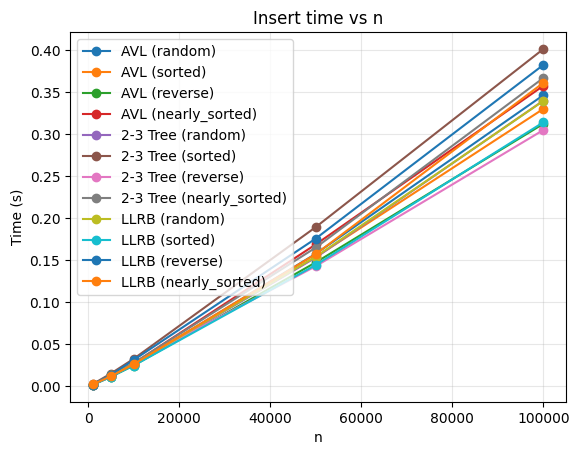

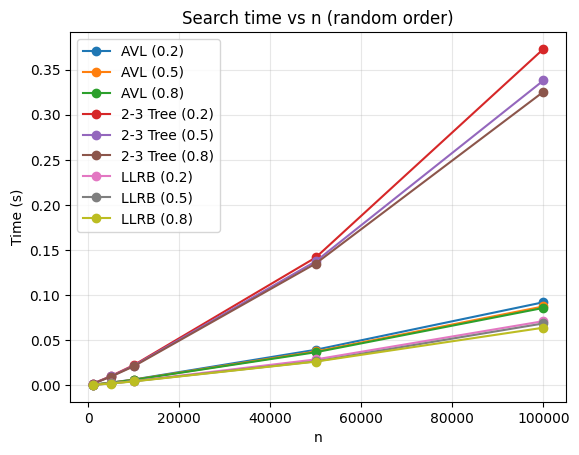

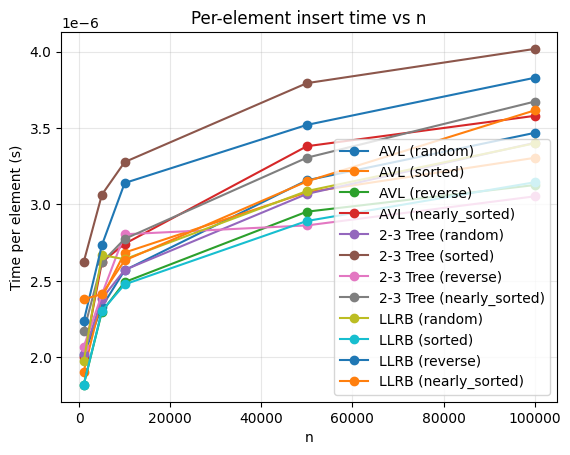

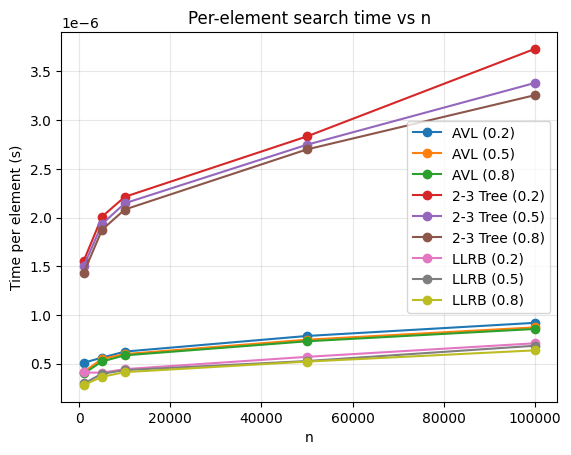

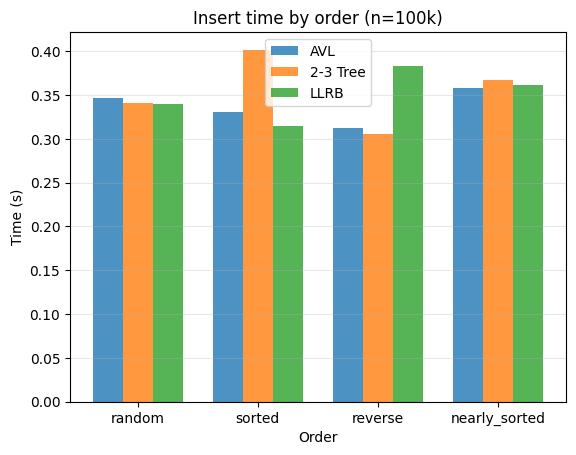

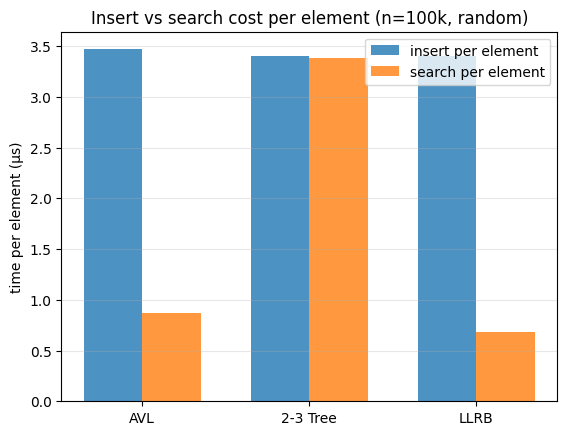

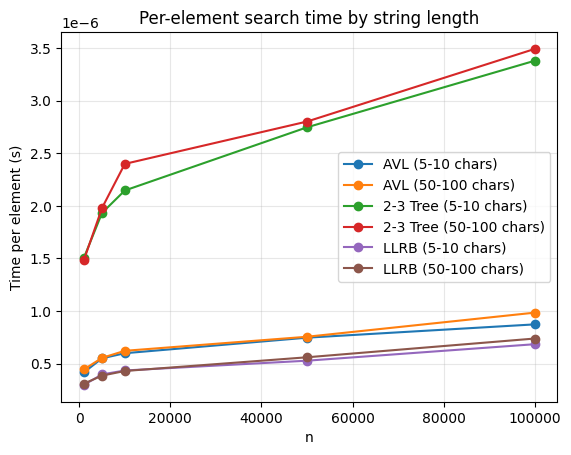

In [11]:
# ADD YOUR TEST CODE HERE

def verify_edge_cases(tree_class, name):
    t = tree_class()
    assert t.searchElement("hello") == False

    t = tree_class()
    assert t.insertElement("hello") == True
    assert t.searchElement("hello") == True
    assert t.searchElement("world") == False

    t = tree_class()
    t.insertElement("hello")
    assert t.insertElement("hello") == False

    t = tree_class()
    for w in ["banana", "apple", "cherry", "date", "elderberry"]:
        t.insertElement(w)
    for w in ["banana", "apple", "cherry", "date", "elderberry"]:
        assert t.searchElement(w) == True
    assert t.searchElement("fig") == False

    print(f"{name}: edge cases passed")


verify_edge_cases(AVLTree, "AVLTree")
verify_edge_cases(TwoThreeTree, "TwoThreeTree")
verify_edge_cases(LLRBBST, "LLRBBST")

avl_experiment = ExperimentalFramework(AVLTree)
avl_experiment.evaluation_suite()

twothree_experiment = ExperimentalFramework(TwoThreeTree)
twothree_experiment.evaluation_suite()

llrb_experiment = ExperimentalFramework(LLRBBST)
llrb_experiment.evaluation_suite()

for result in avl_experiment.evaluation_results:
    print(f"AVL      | n={result['n']}, order={result['order']}, hit_ratio={result['hit_ratio']} -> insert={result['insert_time']:.4f}s, search={result['search_time']:.6f}s")
for result in twothree_experiment.evaluation_results:
    print(f"2-3 Tree | n={result['n']}, order={result['order']}, hit_ratio={result['hit_ratio']} -> insert={result['insert_time']:.4f}s, search={result['search_time']:.6f}s")
for result in llrb_experiment.evaluation_results:
    print(f"LLRB     | n={result['n']}, order={result['order']}, hit_ratio={result['hit_ratio']} -> insert={result['insert_time']:.4f}s, search={result['search_time']:.6f}s")

all_results = {
    'AVL': avl_experiment.evaluation_results,
    '2-3 Tree': twothree_experiment.evaluation_results,
    'LLRB': llrb_experiment.evaluation_results,
}

orders = ["random", "sorted", "reverse", "nearly_sorted"]
hit_ratios = [0.2, 0.5, 0.8]
sizes = [1000, 5000, 10000, 50000, 100000]

# insert time vs n by order
for label, results in all_results.items():
    for order in orders:
        filtered = [r for r in results if r['order'] == order and r['hit_ratio'] == 0.5]
        plt.plot([r['n'] for r in filtered], [r['insert_time'] for r in filtered], marker='o', label=f"{label} ({order})")
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.title('Insert time vs n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# search time vs n by hit ratio
for label, results in all_results.items():
    for hr in hit_ratios:
        filtered = [r for r in results if r['hit_ratio'] == hr and r['order'] == 'random']
        plt.plot([r['n'] for r in filtered], [r['search_time'] for r in filtered], marker='o', label=f"{label} ({hr})")
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.title('Search time vs n (random order)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# per-element insert time vs n
for label, results in all_results.items():
    for order in orders:
        filtered = [r for r in results if r['order'] == order and r['hit_ratio'] == 0.5]
        plt.plot([r['n'] for r in filtered], [r['insert_per_element'] for r in filtered], marker='o', label=f"{label} ({order})")
plt.xlabel('n')
plt.ylabel('Time per element (s)')
plt.title('Per-element insert time vs n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# per-element search time vs n
for label, results in all_results.items():
    for hr in hit_ratios:
        filtered = [r for r in results if r['hit_ratio'] == hr and r['order'] == 'random']
        plt.plot([r['n'] for r in filtered], [r['search_per_element'] for r in filtered], marker='o', label=f"{label} ({hr})")
plt.xlabel('n')
plt.ylabel('Time per element (s)')
plt.title('Per-element search time vs n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# insert time by order at n=100k
n_labels = orders
width = 0.25
for i, (label, results) in enumerate(all_results.items()):
    filtered = [r for r in results if r['n'] == 100000 and r['hit_ratio'] == 0.5]
    times = [r['insert_time'] for r in filtered]
    positions = [x + i * width for x in range(len(orders))]
    plt.bar(positions, times, width, label=label, alpha=0.8)
plt.xticks([x + width for x in range(len(orders))], orders)
plt.xlabel('Order')
plt.ylabel('Time (s)')
plt.title('Insert time by order (n=100k)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# insert vs search cost per element
tree_labels = list(all_results.keys())
insert_vals = []
search_vals = []
for label, results in all_results.items():
    r = [r for r in results if r['n'] == 100000 and r['order'] == 'random' and r['hit_ratio'] == 0.5][0]
    insert_vals.append(r['insert_per_element'] * 1e6)
    search_vals.append(r['search_per_element'] * 1e6)
x = range(len(tree_labels))
plt.bar([i - 0.175 for i in x], insert_vals, 0.35, label='insert per element', alpha=0.8)
plt.bar([i + 0.175 for i in x], search_vals, 0.35, label='search per element', alpha=0.8)
plt.xticks(x, tree_labels)
plt.ylabel('time per element (µs)')
plt.title('Insert vs search cost per element (n=100k, random)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# string length experiment
long_gen = TestDataGenerator(min_length=50, max_length=100)

avl_long = ExperimentalFramework(AVLTree)
avl_long.evaluation_suite(data_generator=long_gen)
twothree_long = ExperimentalFramework(TwoThreeTree)
twothree_long.evaluation_suite(data_generator=long_gen)
llrb_long = ExperimentalFramework(LLRBBST)
llrb_long.evaluation_suite(data_generator=long_gen)

string_results = {
    'AVL (5-10 chars)': avl_experiment.evaluation_results,
    'AVL (50-100 chars)': avl_long.evaluation_results,
    '2-3 Tree (5-10 chars)': twothree_experiment.evaluation_results,
    '2-3 Tree (50-100 chars)': twothree_long.evaluation_results,
    'LLRB (5-10 chars)': llrb_experiment.evaluation_results,
    'LLRB (50-100 chars)': llrb_long.evaluation_results,
}

for label, results in string_results.items():
    filtered = [r for r in results if r['order'] == 'random' and r['hit_ratio'] == 0.5]
    plt.plot([r['n'] for r in filtered], [r['search_per_element'] for r in filtered], marker='o', label=label)
plt.xlabel('n')
plt.ylabel('Time per element (s)')
plt.title('Per-element search time by string length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()